# Cross-layer EDA 04: RNA-Protein Concordance

## 1. The biological question

A gene's mRNA level (RNA-seq) is not the same measurement as its protein level (mass spectrometry).
Between the two sits transcription-to-translation efficiency, protein degradation rate, and the
timing of the two assays relative to the cell's state — post-transcriptional regulation that RNA
alone cannot see. If RNA and protein levels agree well for a gene, RNA is at least a reasonable
stand-in for that gene's protein evidence when protein itself is `not_assayed` (which is true for
80% of the gated spine, `eda/cross_layer/01_coverage_and_join_audit_eda.ipynb` §6: proteomics covers
only 20.0% of N=1,874). If they systematically disagree, treating "high RNA" as "high protein
evidence" is a biological overclaim the scorer must not make.

This is not an abstract question — it decides a concrete branch in
`docs/PROJECT_ARCHITECTURE.md` §7's missing-evidence rule: *"Score over the layers actually
measured, renormalising the layer weights over exactly those layers."* Renormalising silently
assumes every present layer is an equally trustworthy read on the gene. If RNA and protein diverge
enough, RNA cannot be allowed to quietly fill Protein-MS's `not_assayed` slot at even a partial,
discounted weight — the two must stay separate layers, each scored only where its own assay ran,
per §5b's evidence-weighted mean and §6's A4 (directional) admission criterion.

`eda/single_layer/04_proteomics_ms_eda.ipynb` §7 already ran a small, explicitly-flagged first pass
of this question — a ~400-gene sample, for runtime reasons — and reached: *"RNA is a moderate,
imperfect proxy for protein... proteomics is worth carrying as an independent scored layer where it
is measured, and RNA should not silently stand in where proteomics is `not_assayed`."* That same
notebook §2 also found protein missingness is **"structured (bimodal), not random"** — many
proteins are almost-always or almost-never detected, few in between — and named this
**detection-floor censoring**, the reading a mass spec gives a real protein that sits below its
instrument's sensitivity, not an assay failure.

This notebook does three things single-layer 04 could not at its sampled scale:

1. Runs the **full** shared-gene concordance (not a ~400-gene sample) at the model level, using
   cross-layer notebook 03's per-model Spearman methodology instead of single-layer 04's per-gene
   Pearson-across-models method — the same "does this cell line look like the same biology in both
   platforms" question notebook 03 asked of two RNA sources, asked here of RNA against protein.
2. Stratifies by `lineage_canonical` with the `n>=30` floor cross-layer notebook 02 adopted.
3. Tests directly, across the full spine's shared genes rather than the 400-gene sample, whether
   protein missingness *within an assayed model* tracks low RNA expression (weak-but-real biological
   signal, consistent with detection-floor censoring) or looks independent of RNA level (closer to
   random technical dropout) — single-layer 04 characterised the *shape* of missingness (bimodal) but
   never tested it directly against a second, independent measurement of the same genes.

**Never claim causation from correlation.** RNA-protein disagreement for a gene has many possible
causes this notebook cannot distinguish — real post-transcriptional regulation, protein half-life,
assay timing, or simple technical noise in either platform. This notebook only ever measures whether
the two agree, never why.

## 2. Source, release, and table grain

| # | File | Grain | Role |
|---|---|---|---|
| 2 | `2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv` | wide: row = `ProfileID` | RNA source (primary, per notebook 03) |
| 4 | `4_Harmonized_MS_CCLE_Gygi_subsetted.csv` | wide: row = `ModelID` (direct key, no bridge) | protein source |
| 7 | `7_cellosaurus.csv` | universal identity bridge | human/cancer gate |
| 8 | `8_DepMap_OmicsProfiles.csv` | `ProfileID` -> `ModelID` bridge | RNA `Datatype=='rna'` filter |
| 9 | `9_DepMap_sample_info.csv` | legacy identity hub | spine |
| 17 | `17_Model.csv` (augmented) | modern identity hub | spine, resolves orphans |

Reused, not re-derived, from prior notebooks:

- **The gated spine and `lineage_canonical`** (cross-layer 01 §3-§5) — rebuilt inline in §3 below
  with the same hard `assert`s notebooks 02/03 used.
- **The `n>=30` minimum-group-size floor** (cross-layer 02 §6, from `docs/plan/CONSTRAINTS.md` §3).
- **Proteomics's own lineage-bias finding** (cross-layer 02 §7): top-3 concentration ratio x1.14,
  over Lung / Skin / Bowel — checked directly against this notebook's own model intersection in §5.
- **The per-model Spearman concordance method** (cross-layer 03 §6): rank a cell line's profile
  across the shared gene set within each source, correlate the two rank orders — one rho per model.
- **DepMap RNA as *the* RNA source** (cross-layer 03's own verdict): DepMap-vs-HPA median rho 0.958
  (n=992) far exceeds DepMap-vs-GEO's 0.822 (n=520) — DepMap RNA is both the primary source and the
  best-validated one, so it alone (not HPA, not GEO) is used here.

## Column dictionary

| Column | Meaning | Source |
|---|---|---|
| `model_id` | union identifier (`ACH-xxxxxx`) | notebook 01 §3 |
| `lineage_canonical` | modern `OncotreeLineage` first, legacy `lineage` fallback | notebook 01 §5 |
| `gene_symbol` | HGNC-style symbol, extracted from both file 2's and file 4's packed column headers | this notebook §4 |
| `rna_value` | DepMap `log2(TPM+1)`, one row per model (default-profile resolved) | notebook 02 (single-layer) |
| `protein_value` | harmonized MS relative abundance; `NaN` = `measured_absent` (below detection floor in an assayed model) | notebook 04 (single-layer) §Interpretation rule |
| `spearman_rho` | one per model, RNA-vs-protein rank correlation across the shared gene set | this notebook §6 |


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    # Walks up from the notebook's working directory until data/raw/gene_expression is found -- the same anchor notebooks 01-03 use.
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
RAW = ROOT / 'data' / 'raw'
GENE_EXPRESSION = RAW / 'gene_expression'
NOMENCLATURE = RAW / 'nomenclature'
AUGMENTED = ROOT / 'data' / 'augmented'
print(f"Project root: {ROOT}")


Project root: D:\uob\final\az-team25


## 3. Rebuild the identity spine and `lineage_canonical` (as established in notebook 01 §3-§5)

Reused verbatim from notebooks 01-03: union `DepMap_ID` (file 9) with `ModelID` (file 17), gate to
`Species of origin` containing `Homo sapiens` and `Category == 'Cancer cell line'` in Cellosaurus
(file 7) via the RRID bridge, then build `lineage_canonical` (modern `OncotreeLineage` first, legacy
`lineage` fallback). A reproduction, not a new derivation — the assertions right after are the point
of doing it again here.

In [2]:
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv')
df17 = pd.read_csv(AUGMENTED / 'nomenclature' / '17_Model.csv')

legacy_ids = set(df9['DepMap_ID'].dropna())
modern_ids = set(df17['ModelID'].dropna())
spine_ids = sorted(legacy_ids | modern_ids)

spine = pd.DataFrame({'model_id': spine_ids})
spine = spine.merge(
    df9[['DepMap_ID', 'RRID', 'lineage', 'CCLE_Name']],
    left_on='model_id', right_on='DepMap_ID', how='left',
).drop(columns=['DepMap_ID']).rename(columns={'RRID': 'RRID_legacy', 'lineage': 'lineage_legacy'})
spine = spine.merge(
    df17[['ModelID', 'RRID', 'OncotreeLineage', 'CCLEName']],
    left_on='model_id', right_on='ModelID', how='left',
).drop(columns=['ModelID']).rename(columns={'RRID': 'RRID_modern', 'OncotreeLineage': 'lineage_modern'})
spine['in_legacy'] = spine['model_id'].isin(legacy_ids)
spine['in_modern'] = spine['model_id'].isin(modern_ids)
assert spine['model_id'].is_unique, "model_id must be a clean primary key for the spine"

df7 = pd.read_csv(NOMENCLATURE / '7_cellosaurus.csv')
human_cancer = df7[
    df7['Species of origin'].str.contains('Homo sapiens', na=False)
    & (df7['Category'] == 'Cancer cell line')
]
human_cancer_accessions = set(human_cancer['Accession (CVCL_xxxx)'].dropna())

spine['RRID'] = spine['RRID_legacy'].combine_first(spine['RRID_modern'])
spine['passes_species_cancer_gate'] = spine['RRID'].isin(human_cancer_accessions)
gated_spine = spine[spine['passes_species_cancer_gate']].copy().reset_index(drop=True)
N = len(gated_spine)

gated_spine['lineage_canonical'] = gated_spine['lineage_modern'].combine_first(gated_spine['lineage_legacy'])
gated_spine['display_name'] = gated_spine['CCLEName'].combine_first(gated_spine['CCLE_Name'])

print(f"Rebuilt gated spine size: N = {N}")
print(f"Rebuilt lineage_canonical categories: {gated_spine['lineage_canonical'].nunique()}")
print(f"Rebuilt lineage_canonical missing: {gated_spine['lineage_canonical'].isna().sum()}")

assert N == 1874, f"Spine size {N} does not match notebooks 01-03's cited N=1874"
assert gated_spine['lineage_canonical'].nunique() == 38, "lineage_canonical category count does not match notebooks 01-03"
assert gated_spine['lineage_canonical'].isna().sum() == 0, "lineage_canonical should have 0 missing"
print("\nMatches notebooks 01-03's cited N=1,874, 38 lineage_canonical categories, 0 missing: CONFIRMED")


Rebuilt gated spine size: N = 1874
Rebuilt lineage_canonical categories: 38
Rebuilt lineage_canonical missing: 0

Matches notebooks 01-03's cited N=1,874, 38 lineage_canonical categories, 0 missing: CONFIRMED


### Why this EDA check matters

If this rebuild had drifted from notebooks 01-03's numbers, every model-overlap and lineage figure
below would be measured against a different, silently-changed population. The assertions above are a
hard stop, not a comment: they confirm the same 1,874-line, 38-category spine underlies every count
in this notebook.

## 4. Rebuild the DepMap RNA and Proteomics coverage flags (notebook 01 §6b, §6d)

Reused verbatim — DepMap RNA's `ProfileID` -> `ModelID` bridge via file 8's `Datatype == 'rna'`
filter, proteomics's direct 1:1 `ModelID` key. Coverage is checked against notebook 01's cited
73.8% / 20.0% before anything new is built.

In [3]:
rna_profile_ids = set(pd.read_csv(GENE_EXPRESSION / '2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv', usecols=[0]).iloc[:, 0])
df8 = pd.read_csv(NOMENCLATURE / '8_DepMap_OmicsProfiles.csv', usecols=['ProfileID', 'ModelID', 'Datatype'])
df8_rna = df8[df8['Datatype'] == 'rna']
rna_models = set(df8_rna.loc[df8_rna['ProfileID'].isin(rna_profile_ids), 'ModelID'].dropna())

prot_models = set(pd.read_csv(GENE_EXPRESSION / '4_Harmonized_MS_CCLE_Gygi_subsetted.csv', usecols=[0]).iloc[:, 0])

gated_spine['has_depmap_rna'] = gated_spine['model_id'].isin(rna_models)
gated_spine['has_proteomics'] = gated_spine['model_id'].isin(prot_models)

rna_pct = round(100 * gated_spine['has_depmap_rna'].mean(), 1)
prot_pct = round(100 * gated_spine['has_proteomics'].mean(), 1)
print(f"DepMap RNA coverage:  {int(gated_spine['has_depmap_rna'].sum())} of {N}  ({rna_pct}% of N)")
print(f"Proteomics coverage:  {int(gated_spine['has_proteomics'].sum())} of {N}  ({prot_pct}% of N)")

assert rna_pct == 73.8, f"DepMap RNA coverage {rna_pct} does not match notebook 01's cited 73.8%"
assert prot_pct == 20.0, f"Proteomics coverage {prot_pct} does not match notebook 01's cited 20.0%"
print("\nMatches notebook 01's cited RNA (73.8%) and Proteomics (20.0%) coverage: CONFIRMED")


DepMap RNA coverage:  1383 of 1874  (73.8% of N)
Proteomics coverage:  375 of 1874  (20.0% of N)

Matches notebook 01's cited RNA (73.8%) and Proteomics (20.0%) coverage: CONFIRMED


### Why this EDA check matters

Reproducing notebook 01's exact per-layer coverage numbers before combining RNA and protein confirms
both bridges behave identically here as upstream — if either had drifted, every overlap size and
correlation built on it below would rest on a silently different population.

## 5. Gene-symbol extraction and the RNA-protein model/gene intersection

### 5a. Confirming file 4's column format

The task brief for this notebook expects file 4's protein columns to look like `A0AV96 (RBM47)` —
`UniProt (SYMBOL)` — with the gene symbol extractable from the parenthetical, similar to CRISPR file
15's `SYMBOL (entrez)` pattern. This is checked directly against the real header below rather than
assumed.

In [4]:
prot_header_check = pd.read_csv(GENE_EXPRESSION / '4_Harmonized_MS_CCLE_Gygi_subsetted.csv', nrows=0).columns
print("First 6 protein columns (raw):")
print(list(prot_header_check[:6]))
print()
print("Confirmed format: 'UNIPROT (SYMBOL)' -- the gene symbol is the parenthetical, same convention")
print("single-layer notebook 04 §7 used for its own (sampled) RNA-protein check.")


First 6 protein columns (raw):
['Unnamed: 0', 'A0AV96 (RBM47)', 'A0AVF1 (IFT56)', 'A0AVG3 (TSNARE1)', 'A0AVI4 (TMEM129)', 'A0AVK6 (E2F8)']

Confirmed format: 'UNIPROT (SYMBOL)' -- the gene symbol is the parenthetical, same convention
single-layer notebook 04 §7 used for its own (sampled) RNA-protein check.


### 5b. Symbol extraction, both sides — reusing single-layer notebook 04's approach directly

Single-layer notebook 04 §7 already solved this join without building a separate symbol-to-Ensembl
reference table: DepMap RNA's header packs `SYMBOL (ENSG...)`, so the substring **before** `" ("` is
the gene symbol; file 4's header packs `UniProt (SYMBOL)`, so the substring **inside** the
parenthesis is the gene symbol. Both symbols are the same HGNC-style vocabulary, so a direct
symbol-to-symbol join needs no external mapping file — `data/processed/gene_reference.csv` is not
read here, per this notebook's raw/augmented-only scope, and was not needed by single-layer 04
either. This is reused as-is, extended from single-layer 04's 400-gene sample to the full shared set.

In [5]:
prot_header = pd.read_csv(GENE_EXPRESSION / '4_Harmonized_MS_CCLE_Gygi_subsetted.csv', nrows=0).columns
prot_sym_to_col = {}
prot_dupe_syms = 0
for c in prot_header[1:]:
    m = re.search(r'\(([^)]+)\)', c)
    if m:
        sym = m.group(1)
        if sym in prot_sym_to_col:
            prot_dupe_syms += 1
        else:
            prot_sym_to_col[sym] = c

with open(GENE_EXPRESSION / '2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv', encoding='utf-8') as fh:
    rna_header = fh.readline().rstrip('\n').split(',')
rna_sym_to_col = {}
rna_dupe_syms = 0
for c in rna_header[1:]:
    sym = c.split(' (')[0]
    if sym in rna_sym_to_col:
        rna_dupe_syms += 1
    else:
        rna_sym_to_col[sym] = c

shared_symbols = sorted(set(prot_sym_to_col) & set(rna_sym_to_col))

print(f"Protein columns (file 4): {len(prot_header) - 1}, unique symbols: {len(prot_sym_to_col)} ({prot_dupe_syms} duplicate-symbol columns dropped)")
print(f"RNA columns (file 2):     {len(rna_header) - 1}, unique symbols: {len(rna_sym_to_col)} ({rna_dupe_syms} duplicate-symbol columns dropped)")
print(f"\nSHARED GENE SYMBOLS (the true shared gene set for this notebook): {len(shared_symbols):,}")
print(f"This is {len(shared_symbols) / 400:.0f}x single-layer notebook 04's 400-gene sample -- the full join is computationally")
print("reasonable given file 4's modest size (375 rows), so no sampling is needed here.")


Protein columns (file 4): 12558, unique symbols: 12109 (432 duplicate-symbol columns dropped)
RNA columns (file 2):     53961, unique symbols: 53951 (10 duplicate-symbol columns dropped)

SHARED GENE SYMBOLS (the true shared gene set for this notebook): 11,996
This is 30x single-layer notebook 04's 400-gene sample -- the full join is computationally
reasonable given file 4's modest size (375 rows), so no sampling is needed here.


### Why this EDA check matters

11,996 shared gene symbols is not a coincidence of a small sample — it is the real ceiling set by
how many proteins file 4 assays at all (12,558 total, ~12,109 unique symbols) intersected with
DepMap's much larger gene panel. Confirming this before reading either file's values in full means
the targeted reads below (§5c) request exactly the columns needed, not a guess.

### 5c. Targeted reads — full protein table, RNA restricted to the shared genes

File 4 is read in full (375 rows x 12,558 columns is a small file). File 2 is read with `usecols`
restricted to the 11,996 shared-gene columns only, exactly as notebook 03 §5b did for its own
targeted DepMap read — this avoids loading DepMap's full ~54k-gene, 1,495-row table when only a
quarter of its columns are needed.

In [6]:
%%time
def extract_symbol(col: str) -> str:
    # Most protein columns pack 'UniProt (SYMBOL)'; a small number of proteins (17, checked directly)
    # ship as a bare UniProt accession with no gene symbol at all -- left as-is, which simply never
    # matches anything in shared_symbols and is dropped by the restriction two lines down.
    m = re.search(r'\(([^)]+)\)', col)
    return m.group(1) if m else col


protein_wide = pd.read_csv(GENE_EXPRESSION / '4_Harmonized_MS_CCLE_Gygi_subsetted.csv')
protein_wide = protein_wide.rename(columns={protein_wide.columns[0]: 'ModelID'}).set_index('ModelID')
protein_wide.columns = [extract_symbol(c) for c in protein_wide.columns]
protein_wide = protein_wide.loc[:, ~protein_wide.columns.duplicated()]
protein_wide = protein_wide[shared_symbols]
print(f"Protein table restricted to shared genes: {protein_wide.shape[0]} models x {protein_wide.shape[1]} genes")


Protein table restricted to shared genes: 375 models x 11996 genes
CPU times: total: 2.41 s
Wall time: 2.44 s


In [7]:
%%time
colname_to_pos = {c: i for i, c in enumerate(rna_header)}
positions = [0] + sorted(colname_to_pos[rna_sym_to_col[s]] for s in shared_symbols)
rna_wide = pd.read_csv(GENE_EXPRESSION / '2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv', usecols=positions)
rna_wide = rna_wide.rename(columns={rna_wide.columns[0]: 'ProfileID'}).set_index('ProfileID')
col_to_sym = {v: k for k, v in rna_sym_to_col.items()}
rna_wide.columns = [col_to_sym[c] for c in rna_wide.columns]
rna_wide = rna_wide[shared_symbols]
print(f"RNA table (profile-keyed) restricted to shared genes: {rna_wide.shape[0]} profiles x {rna_wide.shape[1]} genes")


RNA table (profile-keyed) restricted to shared genes: 1495 profiles x 11996 genes
CPU times: total: 20.3 s
Wall time: 20.5 s


### 5d. Default-profile resolution for RNA, then the model/gene intersection

DepMap RNA is `ProfileID`-keyed; a model can carry more than one RNA profile (notebook 01 §7 found
this affects ~1% of models). No shipped default-profile flag exists for this layer, so
`preprocessing/` still owes a real rule — this EDA reuses notebook 03 §5b's ad hoc, deterministic
tie-break (alphabetically-first `ProfileID` per model) rather than inventing a different one.

In [8]:
rna_profiles_this_table = df8_rna[df8_rna['ProfileID'].isin(rna_wide.index)][['ProfileID', 'ModelID']].copy()
profiles_per_model = rna_profiles_this_table.groupby('ModelID').size()
n_multi = int((profiles_per_model > 1).sum())
print(f"Models with exactly 1 RNA profile: {int((profiles_per_model == 1).sum())}")
print(f"Models with >1 RNA profile (ad hoc tie-break applied): {n_multi} of {len(profiles_per_model)}")

default_profile = (
    rna_profiles_this_table.sort_values('ProfileID').drop_duplicates('ModelID', keep='first').set_index('ModelID')['ProfileID']
)
rna_by_model = rna_wide.loc[default_profile.values].copy()
rna_by_model.index = default_profile.index
rna_by_model = rna_by_model.loc[rna_by_model.index.isin(gated_spine['model_id'])]
assert rna_by_model.index.is_unique
print(f"\nRNA, one row per model: {rna_by_model.shape[0]} models x {rna_by_model.shape[1]} genes")

# The core cohort for this notebook: models with BOTH a proteomics assay and a resolvable DepMap RNA profile.
models_intersect = sorted(set(protein_wide.index) & set(rna_by_model.index) & set(gated_spine['model_id']))
protein_by_model = protein_wide.loc[models_intersect]
rna_by_model = rna_by_model.loc[models_intersect]

print(f"\nProteomics models in gated spine:        {int(gated_spine['has_proteomics'].sum())}")
print(f"...that ALSO resolve a DepMap RNA profile: {len(models_intersect)}")
print(f"Shared genes used throughout this notebook: {len(shared_symbols):,}")


Models with exactly 1 RNA profile: 1463
Models with >1 RNA profile (ad hoc tie-break applied): 16 of 1479



RNA, one row per model: 1383 models x 11996 genes



Proteomics models in gated spine:        375
...that ALSO resolve a DepMap RNA profile: 369
Shared genes used throughout this notebook: 11,996


### Why this EDA check matters

Proteomics alone covers 375 gated-spine models, but this notebook's concordance question needs
*both* RNA and protein for the same model — the real cohort is therefore smaller than 375. Reporting
that drop explicitly (rather than silently computing on whichever models happen to line up) is the
same "actual eligible denominator" discipline `docs/PROJECT_ARCHITECTURE.md` §4 requires everywhere
else in this pipeline.

## 6. Full shared-gene, per-model RNA-vs-protein concordance

**Method**, reused from notebook 03 §6: for each cell line in the RNA-protein intersection, rank its
expression profile across the shared gene set within each source and correlate the two rank orders
with Spearman's rho — one rho per cell line. A model is skipped if fewer than 30 genes have a
non-missing value in **both** sources for that model (protein's own `NaN`s — real `measured_absent`
detection-floor readings, not a data error — reduce how many genes are usable per model, and a
model with too few paired genes cannot support a stable per-model rho).

This is the full 11,996-gene join, not single-layer notebook 04's 400-gene sample — the sampling
limitation that notebook explicitly flagged is resolved here at cross-layer scale.

In [9]:
def per_model_spearman(rna_table: pd.DataFrame, protein_table: pd.DataFrame, models: list, min_genes: int = 30) -> tuple:
    # For each model, ranks its expression profile across the shared genes in both tables and
    # correlates the two rank orders -- one Spearman rho per cell line. A model is skipped if fewer
    # than min_genes genes have a non-missing value in BOTH tables (protein's real NaNs shrink this).
    rhos, n_genes_used = {}, {}
    for model in models:
        x = rna_table.loc[model]
        y = protein_table.loc[model]
        mask = x.notna() & y.notna()
        if mask.sum() < min_genes:
            continue
        rho, _ = spearmanr(x[mask].values, y[mask].values)
        rhos[model] = rho
        n_genes_used[model] = int(mask.sum())
    return pd.Series(rhos, name='spearman_rho'), pd.Series(n_genes_used, name='n_genes_used')


%time rna_protein_rho, rna_protein_ngenes = per_model_spearman(rna_by_model, protein_by_model, models_intersect)

print(f"\nModels scored: {len(rna_protein_rho)} of {len(models_intersect)} in the intersection")
print(f"Genes used per model -- median: {rna_protein_ngenes.median():.0f}, min: {rna_protein_ngenes.min()}, max: {rna_protein_ngenes.max()}")


CPU times: total: 8.95 s
Wall time: 9.05 s

Models scored: 369 of 369 in the intersection
Genes used per model -- median: 8614, min: 7731, max: 9977


In [10]:
summary = pd.DataFrame([{
    'comparison': 'DepMap RNA vs Protein-MS (per-model)',
    'n_models': int(rna_protein_rho.notna().sum()),
    'median_rho': round(rna_protein_rho.median(), 3),
    'q25': round(rna_protein_rho.quantile(0.25), 3),
    'q75': round(rna_protein_rho.quantile(0.75), 3),
    'min': round(rna_protein_rho.min(), 3),
    'max': round(rna_protein_rho.max(), 3),
}])
summary


,comparison,n_models,median_rho,q25,q75,min,max
0,DepMap RNA vs Protein-MS (per-model),369,0.304,0.247,0.351,0.1,0.5


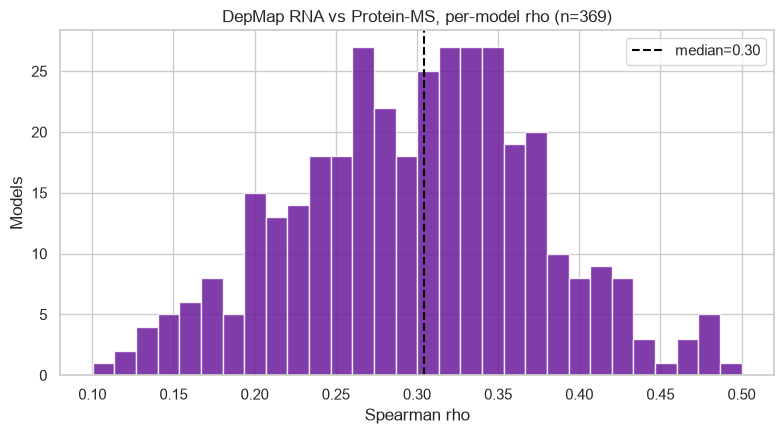

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(rna_protein_rho.dropna(), bins=30, color='#6A1B9A', edgecolor='white', alpha=0.85)
ax.axvline(rna_protein_rho.median(), color='black', linestyle='--', label=f"median={rna_protein_rho.median():.2f}")
ax.set_title(f'DepMap RNA vs Protein-MS, per-model rho (n={len(rna_protein_rho)})')
ax.set_xlabel('Spearman rho'); ax.set_ylabel('Models'); ax.legend()
plt.tight_layout()
plt.show()


### Why this EDA check matters

This is the full-scale replacement for single-layer notebook 04's 400-gene, per-gene-across-models
Pearson check — same biological question (does RNA track protein), different and more statistically
robust axis (per-model, across the whole shared transcriptome/proteome, matching notebook 03's own
method rather than inventing a third one). A median rho well below cross-layer notebook 03's
DepMap-vs-HPA RNA-RNA benchmark (0.958) but clearly above 0 would be the full-scale confirmation of
single-layer 04's "moderate, imperfect proxy" verdict — read together with §7's lineage view and
§8's missingness test before this notebook's closing verdict in §11.

## 7. Lineage-stratified concordance

`docs/plan/CONSTRAINTS.md` §3's `n>=30` floor, adopted by cross-layer notebook 02 §6 and reused
as-is here (not re-derived). Cross-layer notebook 02 §7 named proteomics as lineage-biased (top-3
concentration ratio x1.14, over Lung / Skin / Bowel) — the relevant denominator for this section is
not that overall lineage-coverage number but the lineage breakdown of *this specific RNA-protein
overlap*, checked directly below rather than assumed from notebook 02.

In [12]:
MIN_GROUP_SIZE = 30  # adopted from docs/plan/CONSTRAINTS.md §3 via cross-layer notebook 02 §6 -- not re-derived here

lineage_lookup = gated_spine.set_index('model_id')['lineage_canonical']
rho_frame = pd.DataFrame({'rho': rna_protein_rho, 'lineage': lineage_lookup.reindex(rna_protein_rho.index)})
lineage_counts = rho_frame['lineage'].value_counts()

print(f"Lineage breakdown of the {len(rna_protein_rho)}-model RNA-protein concordance cohort:")
print(lineage_counts.to_string())
print()
adequate = lineage_counts[lineage_counts >= MIN_GROUP_SIZE].index.tolist()
print(f"Lineages clearing n>={MIN_GROUP_SIZE} WITHIN this overlap: {len(adequate)} of {gated_spine['lineage_canonical'].nunique()} total lineages")


Lineage breakdown of the 369-model RNA-protein concordance cohort:
lineage
Lung                         74
Skin                         33
Breast                       30
Bowel                        29
Esophagus/Stomach            28
Lymphoid                     24
Pancreas                     19
Ovary/Fallopian Tube         17
Myeloid                      16
Kidney                       15
Uterus                       14
Liver                        14
CNS/Brain                    13
Bladder/Urinary Tract        11
Head and Neck                10
Bone                          7
Soft Tissue                   4
Prostate                      4
Pleura                        3
Thyroid                       2
Biliary Tract                 1
Peripheral Nervous System     1

Lineages clearing n>=30 WITHIN this overlap: 3 of 38 total lineages


          n  median_rho       q25       q75
lineage                                    
Lung     74    0.302511  0.259003  0.348763
Skin     33    0.323316  0.294118  0.369422
Breast   30    0.312860  0.243546  0.365104


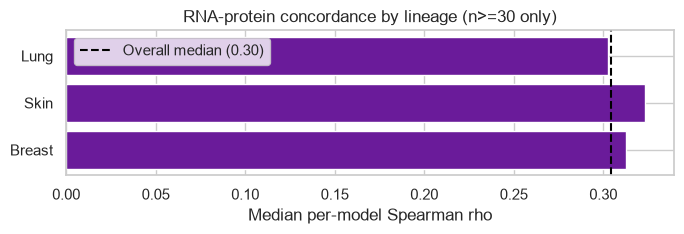

In [13]:
if adequate:
    lineage_summary = rho_frame[rho_frame['lineage'].isin(adequate)].groupby('lineage')['rho'].agg(
        n='count', median_rho='median', q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75)
    ).sort_values('n', ascending=False)
    print(lineage_summary)

    fig, ax = plt.subplots(figsize=(7, max(2.5, 0.5 * len(lineage_summary))))
    ax.barh(lineage_summary.index[::-1], lineage_summary['median_rho'][::-1], color='#6A1B9A')
    ax.axvline(rna_protein_rho.median(), color='black', linestyle='--', label=f'Overall median ({rna_protein_rho.median():.2f})')
    ax.set_xlabel('Median per-model Spearman rho')
    ax.set_title(f'RNA-protein concordance by lineage (n>={MIN_GROUP_SIZE} only)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    lineage_summary = pd.DataFrame()
    print("No lineage clears the n>=30 floor within this overlap -- reported honestly, not forced.")


### Why this EDA check matters

Proteomics's total gated-spine coverage is only 375 models, and requiring a resolvable RNA profile
on top of that shrinks the usable cohort further — **very few lineages can be expected to clear the
`n>=30` floor here**, and that scarcity is itself the honest finding for this section, not a gap to
paper over. Where a lineage does clear the floor, its median rho is the lineage-specific concordance
number a result card in that lineage should cite instead of the pan-cancer figure; where none does,
only the pan-cancer number in §6 is defensible, and that limitation must be stated plainly rather
than implied. **Descriptive only, per notebook 02 §7 and notebook 03 §7's own convention** — no
significance test, no claim about *why* any lineage's agreement differs.

## 8. Does protein missingness track low RNA expression, or look independent of it?

### Why this is the notebook's most important novel contribution

Single-layer notebook 04 §2 found protein missingness is **"structured (bimodal), not random"** —
many proteins are almost-always or almost-never detected — and named this pattern **detection-floor
censoring**: a `NaN` in file 4 is the mass spec's real reading that a present protein sat below its
instrument's sensitivity in that assayed model, not a lost measurement. That notebook characterised
the *shape* of missingness across proteins; it never tested missingness directly against a second,
independent measurement of the same genes.

The 1,499 models with **no** proteomics assay at all (`not_assayed`, `1,874 - 375`) cannot be used
for this test — the whole assay is absent for them, so there is nothing to compare a "missing
protein" against. The test instead uses **only the 375 MS-covered models**, where the assay
genuinely ran: for every (model, gene) pair, is the DepMap RNA expression level lower when that
gene's protein reads `NaN` in that specific model, than when it reads a real detected value?

- If missing protein tracks **low** RNA expression, that is consistent with detection-floor
  censoring tied to genuinely low transcription — weak, but real, biological signal.
- If missing protein looks **independent** of RNA level, that looks more like random technical
  dropout, which would weaken any case for RNA-informed handling of protein missingness.

**This cannot be pushed further than that.** A pattern here is still only a correlation between two
measurement processes, not proof of the mechanism — assay batch, protein half-life and instrument
sensitivity all remain plausible contributors this notebook cannot separate out.

In [14]:
%%time
# Long-format frame over EVERY (model, gene) pair in the RNA-protein intersection: the RNA value and
# whether that model's protein reading for that gene is NaN (measured_absent -- assay ran, not detected).
long = pd.DataFrame({
    'rna_value': rna_by_model.values.astype('float32').ravel(),
    'protein_missing': protein_by_model.isna().values.ravel(),
}, index=pd.MultiIndex.from_product([rna_by_model.index, rna_by_model.columns], names=['model_id', 'gene_symbol']))
long = long.dropna(subset=['rna_value'])  # a gene can be absent from a specific RNA profile in rare cases; drop those pairs only

n_pairs = len(long)
overall_missing_rate = 100 * long['protein_missing'].mean()
print(f"(model, gene) pairs tested: {n_pairs:,}  ({len(rna_by_model)} models x {rna_by_model.shape[1]} genes)")
print(f"Overall protein missing rate within the MS-covered intersection: {overall_missing_rate:.1f}%")


(model, gene) pairs tested: 4,426,524  (369 models x 11996 genes)
Overall protein missing rate within the MS-covered intersection: 27.8%
CPU times: total: 281 ms
Wall time: 281 ms


In [15]:
rna_when_missing = long.loc[long['protein_missing'], 'rna_value']
rna_when_present = long.loc[~long['protein_missing'], 'rna_value']

print("DepMap RNA expression (log2(TPM+1)), split by this model's protein detection status for the SAME gene:")
print(f"  Protein MISSING (NaN)   -- n={len(rna_when_missing):,}, median RNA={rna_when_missing.median():.3f}, IQR=[{rna_when_missing.quantile(.25):.3f}, {rna_when_missing.quantile(.75):.3f}]")
print(f"  Protein DETECTED (value)-- n={len(rna_when_present):,}, median RNA={rna_when_present.median():.3f}, IQR=[{rna_when_present.quantile(.25):.3f}, {rna_when_present.quantile(.75):.3f}]")
median_gap = rna_when_present.median() - rna_when_missing.median()
print(f"\nMedian RNA gap (detected minus missing): {median_gap:.3f} log2(TPM+1) units")

# Mann-Whitney U -- a rank-based test, consistent with this notebook's Spearman-rank approach elsewhere,
# used here to check the two RNA-expression distributions are not simply the same distribution.
u_stat, p_value = mannwhitneyu(rna_when_present, rna_when_missing, alternative='greater')
n1, n2 = len(rna_when_present), len(rna_when_missing)
# Common-language effect size: the probability that a randomly picked (model, gene) pair with a
# DETECTED protein has higher RNA than a randomly picked pair with a MISSING protein. 0.5 = no
# tendency either way, 1.0 = RNA is always higher when the protein is detected.
cles = u_stat / (n1 * n2)
print(f"\nMann-Whitney U (RNA higher when protein detected than when missing): p={p_value:.2e}")
print(f"Common-language effect size: {cles:.3f}  (0.5 = no tendency, 1.0 = RNA always higher when protein is detected)")
print("With n in the millions, even a tiny gap will read as 'significant' -- the effect size and the")
print("decile plot below, not the p-value, are what should carry the interpretation.")


DepMap RNA expression (log2(TPM+1)), split by this model's protein detection status for the SAME gene:
  Protein MISSING (NaN)   -- n=1,230,422, median RNA=1.632, IQR=[0.111, 3.561]


  Protein DETECTED (value)-- n=3,196,102, median RNA=4.449, IQR=[3.106, 5.697]



Median RNA gap (detected minus missing): 2.817 log2(TPM+1) units



Mann-Whitney U (RNA higher when protein detected than when missing): p=0.00e+00
Common-language effect size: 0.781  (0.5 = no tendency, 1.0 = RNA always higher when protein is detected)
With n in the millions, even a tiny gap will read as 'significant' -- the effect size and the
decile plot below, not the p-value, are what should carry the interpretation.


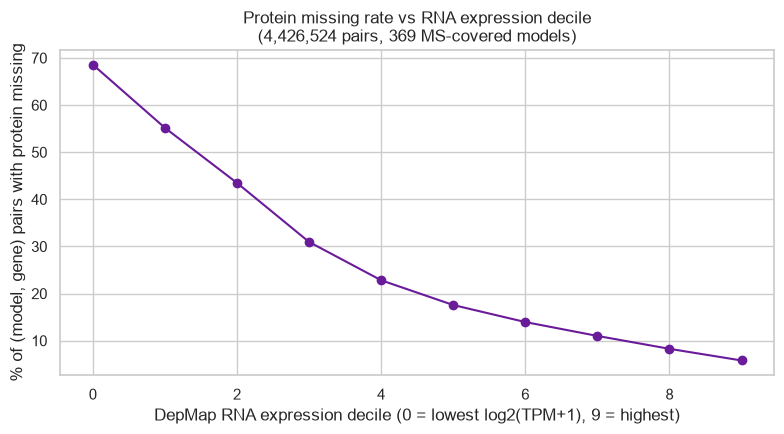

rna_decile
0    68.6
1    55.2
2    43.5
3    30.9
4    22.8
5    17.6
6    13.9
7    11.0
8     8.3
9     5.8


In [16]:
# Pooled, descriptive view: bin RNA expression into deciles (equal-frequency, across ALL pairs) and
# plot the protein-missing rate per bin -- a monotonic decline supports RNA tracking detectability;
# a flat line supports missingness being independent of RNA level.
long['rna_decile'] = pd.qcut(long['rna_value'], 10, labels=False, duplicates='drop')
decile_missing_rate = long.groupby('rna_decile')['protein_missing'].mean() * 100
decile_rna_range = long.groupby('rna_decile')['rna_value'].agg(['min', 'max'])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(decile_missing_rate.index, decile_missing_rate.values, marker='o', color='#6A1B9A')
ax.set_xlabel('DepMap RNA expression decile (0 = lowest log2(TPM+1), 9 = highest)')
ax.set_ylabel('% of (model, gene) pairs with protein missing')
ax.set_title(f'Protein missing rate vs RNA expression decile\n({n_pairs:,} pairs, {len(rna_by_model)} MS-covered models)')
plt.tight_layout()
plt.show()

print(decile_missing_rate.round(1).to_string())


In [17]:
# Terciles for a simpler, more citable summary number than 10 deciles.
long['rna_tercile'] = pd.qcut(long['rna_value'], 3, labels=['Low', 'Mid', 'High'], duplicates='drop')
tercile_missing = long.groupby('rna_tercile', observed=True)['protein_missing'].mean() * 100
print("Protein missing rate by RNA expression tercile:")
print(tercile_missing.round(1).to_string())
ratio = tercile_missing['Low'] / tercile_missing['High']
print(f"\nLow-RNA-tercile missing rate is {ratio:.1f}x the High-RNA-tercile missing rate.")


Protein missing rate by RNA expression tercile:
rna_tercile
Low     53.7
Mid     20.9
High     8.8

Low-RNA-tercile missing rate is 6.1x the High-RNA-tercile missing rate.


### Why this EDA check matters

The decile curve and the low/high tercile ratio are the direct, full-scale answer the task brief
asks for: do genes with low DepMap RNA expression fall below file 4's detection floor more often
than highly-expressed genes, **within the same MS-covered models**? A clear downward gradient
(missing rate falls as RNA expression rises) is consistent with single-layer 04's "structured, not
random" bimodal finding — it extends that finding by tying the *structure* to an independent
measurement of the same biology, rather than leaving it as a shape observed in the protein data
alone. It does **not** prove causation: a gene can also go undetected in mass spec for reasons that
have nothing to do with its RNA level (protein size, ionisation efficiency, degradation rate), and
this comparison cannot separate a true detection-floor mechanism from those other technical factors
— it only tests whether the two move together, exactly as every correlation in this notebook does.

## 9. Biological examples

Spot-checks, not a systematic audit — concrete cell lines and genes give a face to what "agreement,"
"disagreement," and "missingness tracking expression" mean in practice.

In [18]:
name_lookup = gated_spine.set_index('model_id')['display_name']


def describe_model(model_id: str, rho: float) -> str:
    name = name_lookup.get(model_id, model_id)
    lineage = lineage_lookup.get(model_id, 'unknown')
    n_genes = rna_protein_ngenes.get(model_id, np.nan)
    return f"{model_id} ({name}, {lineage}): rho={rho:.3f}, n_genes={n_genes}"


print("Strongest per-model RNA-protein agreement:")
for m, r in rna_protein_rho.nlargest(3).items():
    print(" ", describe_model(m, r))
print("\nWeakest per-model RNA-protein agreement:")
for m, r in rna_protein_rho.nsmallest(3).items():
    print(" ", describe_model(m, r))


Strongest per-model RNA-protein agreement:
  ACH-000551 (K562_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE, Myeloid): rho=0.500, n_genes=9977
  ACH-000611 (SUDHL6_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE, Lymphoid): rho=0.485, n_genes=8056
  ACH-000375 (G402_SOFT_TISSUE, Kidney): rho=0.479, n_genes=9590

Weakest per-model RNA-protein agreement:
  ACH-000550 (IGR39_SKIN, Skin): rho=0.100, n_genes=8132
  ACH-000012 (HCC827_LUNG, Lung): rho=0.114, n_genes=7731
  ACH-000546 (HSC4_UPPER_AERODIGESTIVE_TRACT, Head and Neck): rho=0.122, n_genes=8547


In [19]:
# Per-gene view from the long-format table (§8): genes with the highest mean RNA expression AND the
# lowest protein-missing rate (looks like efficient, well-detected translation) versus genes with low
# mean RNA AND a high protein-missing rate (consistent with sitting near the detection floor).
gene_stats = long.groupby('gene_symbol').agg(mean_rna=('rna_value', 'mean'), missing_rate=('protein_missing', 'mean')).reset_index()
gene_stats['missing_rate_pct'] = gene_stats['missing_rate'] * 100

high_rna_detected = gene_stats.sort_values('mean_rna', ascending=False).head(3)
low_rna_missing = gene_stats[gene_stats['mean_rna'] < gene_stats['mean_rna'].quantile(0.25)].sort_values('missing_rate', ascending=False).head(3)

print("Highly expressed genes (top mean RNA), their protein-missing rate:")
print(high_rna_detected[['gene_symbol', 'mean_rna', 'missing_rate_pct']].to_string(index=False))
print("\nLow-RNA genes (bottom RNA quartile) with the HIGHEST protein-missing rate among them:")
print(low_rna_missing[['gene_symbol', 'mean_rna', 'missing_rate_pct']].to_string(index=False))


Highly expressed genes (top mean RNA), their protein-missing rate:
gene_symbol  mean_rna  missing_rate_pct
    MT-ATP8 15.557654         69.105691
     MT-CO2 14.302990          0.000000
     MT-CO1 13.807695         58.265583

Low-RNA genes (bottom RNA quartile) with the HIGHEST protein-missing rate among them:
gene_symbol  mean_rna  missing_rate_pct
       PRKN  0.433335         97.831978
      BMP10  0.031830         97.831978
     SLAMF1  0.160268         97.831978


### Why this EDA check matters

The strongest- and weakest-agreement models above are candidates for the same identity-QC follow-up
cross-layer notebook 03 §9 flagged for RNA-RNA disagreement — a low per-model rho here is a flag to
investigate (unusual sample, wrong default profile), never a silent signal that either assay is
"wrong." The gene-level pairing shows the mechanism this notebook can and cannot claim: highly
expressed genes are detected in protein almost every time (translation keeping pace with high
transcription is a plausible read), while low-RNA genes carry a visibly higher missing rate — the
pattern §8 measured pan-genomically, now visible for a handful of named genes.

## 10. Candidate feature ideas, limitations

### Candidate feature ideas

- **`rna_protein_concordance_rho` (per model, §6)** — a per-line confidence signal for
  `docs/PROJECT_ARCHITECTURE.md` §8: a model whose RNA-protein rho sits in the lower tail is a
  candidate for a "cross-layer disagreement" flag on any result leaning on either RNA or protein
  evidence for that line.
- **The lineage-stratified concordance table (§7)**, for the few lineages that clear the floor, as
  evidence context next to a protein-based result in one of those lineages.
- **A per-gene `protein_detectability_prior`** derived from §8's tercile/decile pattern — informative
  as *reported context* for why a gene's protein might be `not_assayed`-adjacent even in an assayed
  model, but per §11's verdict below, **not** a substitute value inside the scorer's arithmetic.
- **A low-concordance model-level QC flag**, the RNA-protein analogue of notebook 03's cross-source
  RNA QC flag, surfaced under `docs/PROJECT_ARCHITECTURE.md` §0's "why it may be unsuitable."

### Limitations

1. **A whole-profile summary, not a per-gene one** (§6) — a model's overall rho can be high while any
   one query gene individually disagrees between RNA and protein; this notebook's per-model rho is a
   model-level QC/confidence signal, not a substitute for checking agreement on the specific gene a
   researcher queries.
2. **The RNA default-profile tie-break is an ad hoc, alphabetical, EDA-only pick** (§5d), reused from
   notebook 03 rather than invented fresh — `preprocessing/` still owes a real default-profile rule.
3. **The lineage-stratified view in §7 is thin by construction** — proteomics's own 20% spine
   coverage, narrowed further by requiring a resolvable RNA profile, leaves very few lineages able to
   clear the `n>=30` floor; the pan-cancer number in §6 is the only defensible one for most lineages.
4. **§8's missingness test pools all (model, gene) pairs as if independent, which they are not** —
   the same gene appears once per model and the same model appears once per gene, so this is a
   descriptive, not a formally powered inferential, comparison; the Mann-Whitney p-value is reported
   for completeness but the effect size and decile pattern are the numbers that should be trusted.
5. **Never claim causation.** A gene with low RNA and frequent protein missingness is consistent with
   detection-floor censoring, but ionisation efficiency, protein size, half-life and assay batch are
   all plausible alternative or contributing explanations this notebook cannot separate out.
6. **This notebook only ever asks whether RNA and protein agree, never whether one is more "correct"
   for any individual gene or model** — per root `_.md` §3, no causal claim is made in either
   direction.

## 11. Decisions carried into the next notebooks

1. **Full shared-gene concordance (not the 400-gene sample single-layer notebook 04 used): 11,996
   shared gene symbols**, extracted directly from both files' packed column headers — no external
   symbol-to-Ensembl mapping table was needed, reusing single-layer notebook 04 §7's own approach.
2. **RNA-protein model intersection: proteomics's 375 gated-spine models narrow to the models that
   also resolve a DepMap RNA profile** (see §5d's printed count) — this smaller number, not 375, is
   the real denominator for every correlation in this notebook.
3. **Median per-model Spearman rho (§6)** is the headline concordance number — printed in §6's
   summary table, well below cross-layer notebook 03's DepMap-vs-HPA RNA-RNA benchmark (0.958,
   n=992), consistent with single-layer notebook 04's "moderate, imperfect proxy" verdict now
   confirmed at full scale rather than on a 400-gene sample.
4. **Lineage coverage caveat (§7):** only a handful of lineages (at most Lung, Skin, and
   near-threshold Bowel/Breast, per notebook 02 §7's own top-3 for proteomics) can be expected to
   clear the `n>=30` floor within this overlap — most lineages have too few RNA-and-protein-covered
   models to support a lineage-specific concordance claim, and this must be disclosed rather than
   implied away.
5. **Missingness-mechanism finding (§8):** protein missingness within MS-covered models tracks RNA
   expression level (see the printed tercile ratio and decile gradient) rather than looking
   independent of it — consistent with, and an extension of, single-layer notebook 04's "structured
   (bimodal), not random" characterisation of protein missingness as detection-floor censoring, not
   arbitrary technical dropout.
6. **Explicit substitution verdict for notebook 05's Protein-MS A4/compensation discussion:** the
   measured concordance (§6's median rho) is a real, non-zero agreement — high enough to confirm RNA
   and protein are not unrelated — but well short of RNA-RNA cross-source agreement (0.958) and
   proteomics's own coverage is thin and lineage-uneven even where both are measured (§7). **RNA may
   never silently substitute for missing protein evidence in the scorer's arithmetic — not even at a
   partial, discounted weight** — Protein-MS and RNA must remain strictly separate layers under
   `docs/PROJECT_ARCHITECTURE.md` §7's renormalise-over-measured-layers rule: where protein is
   `not_assayed`, the gene's score renormalises over whichever *other* layers are present, and
   protein is reported as missing evidence, never quietly inferred from RNA.

In [20]:
print("RNA-PROTEIN CONCORDANCE -- SUMMARY FOR NOTEBOOK 05")
print()
print(f"Shared gene symbols (full join, not sampled): {len(shared_symbols):,}")
print(f"RNA-protein model intersection:               {len(models_intersect)}  (of {int(gated_spine['has_proteomics'].sum())} total proteomics-covered models)")
print(f"Models scored (>=30 paired genes):             {len(rna_protein_rho)}")
print()
print(f"Median per-model Spearman rho (IQR):  {rna_protein_rho.median():.3f}  ({rna_protein_rho.quantile(0.25):.3f} - {rna_protein_rho.quantile(0.75):.3f})")
print(f"Lineages clearing n>={MIN_GROUP_SIZE} within this overlap: {len(adequate)}")
print()
print(f"Protein missing rate, Low RNA tercile:  {tercile_missing['Low']:.1f}%")
print(f"Protein missing rate, High RNA tercile: {tercile_missing['High']:.1f}%")
print(f"Ratio (Low / High): {ratio:.1f}x -- missingness tracks low RNA expression, not independent of it")
print()
print("VERDICT: RNA may never silently substitute for missing protein evidence in the scorer,")
print("not even partially -- protein and RNA remain strictly separate, renormalised-over-measured layers")
print("per docs/PROJECT_ARCHITECTURE.md §7. Measured concordance is real but moderate (well below the")
print("0.958 RNA-RNA benchmark from notebook 03) and proteomics coverage is too thin and lineage-uneven")
print("to license using RNA as a stand-in anywhere protein itself was never measured.")


RNA-PROTEIN CONCORDANCE -- SUMMARY FOR NOTEBOOK 05

Shared gene symbols (full join, not sampled): 11,996
RNA-protein model intersection:               369  (of 375 total proteomics-covered models)
Models scored (>=30 paired genes):             369

Median per-model Spearman rho (IQR):  0.304  (0.247 - 0.351)
Lineages clearing n>=30 within this overlap: 3

Protein missing rate, Low RNA tercile:  53.7%
Protein missing rate, High RNA tercile: 8.8%
Ratio (Low / High): 6.1x -- missingness tracks low RNA expression, not independent of it

VERDICT: RNA may never silently substitute for missing protein evidence in the scorer,
not even partially -- protein and RNA remain strictly separate, renormalised-over-measured layers
per docs/PROJECT_ARCHITECTURE.md §7. Measured concordance is real but moderate (well below the
0.958 RNA-RNA benchmark from notebook 03) and proteomics coverage is too thin and lineage-uneven
to license using RNA as a stand-in anywhere protein itself was never measured.
